# PCA ablations

Compare PCA-sweep intervention statistics and probe quality as a function of the PCA component count.

This notebook:
- discovers PCA-sweep intervention files for a chosen dataset, model, layer, and probe dimension
- extracts accuracy-drop and logit-difference summaries from the intervention aggregates
- loads the matching probe artifacts for the same PCA component counts
- plots intervention behavior alongside probe quality

In [1]:
# Parameters
DEPTH_RANGE = [1, 2]
STEPS_RANGE = [1, 2]
SPARSITY_RANGE = None
NUM_SAMPLES = 1000

MODEL_ID = "DeepSeek-R1-Distill-Qwen-7B"
LAYER = 21
PROJ_DIM = 5
BUCKET = "exact"  # e.g. exact, partial, zero, all
NORMALIZED = False
INCLUDE_BASELINES = True
PROBE_DISTANCE_SPLIT = "test_exact"
PROBE_DEPTH_SPLIT = "test_exact"

In [2]:
from pathlib import Path
import sys
from typing import Any, Dict, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd().resolve()
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "cutter").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cutter/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from cutter.utils.shared import paths as path_utils

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROBE_COLOR = "#1d4ed8"
TREE_PCA_COLOR = "#6b7280"
COT_PCA_COLOR = "#9ca3af"
RANDOM_COLOR = "#d1d5db"
FULL_SPACE_COLOR = "#111827"
DISTANCE_COLOR = "#1d4ed8"
DEPTH_COLOR = "#b91c1c"

In [3]:
def _parse_int_range(values: Iterable[int] | int, name: str, min_value: int = 1) -> tuple[int, int]:
    if isinstance(values, (int, float)):
        values = [int(values)]
    values = list(values)
    if len(values) == 1:
        range_min = range_max = int(values[0])
    elif len(values) == 2:
        range_min, range_max = [int(v) for v in values]
    else:
        raise ValueError(f"{name} must have length 1 or 2")
    if range_min < min_value or range_max < min_value or range_max < range_min:
        raise ValueError(f"{name} must satisfy {min_value} <= min <= max")
    return range_min, range_max


def _parse_float_range(values, name: str):
    if values is None:
        return None
    if isinstance(values, (int, float)):
        values = [float(values)]
    values = list(values)
    if len(values) == 1:
        range_min = range_max = float(values[0])
    elif len(values) == 2:
        range_min, range_max = [float(v) for v in values]
    else:
        raise ValueError(f"{name} must have length 1 or 2")
    if range_min <= 0 or range_max <= 0 or range_max < range_min:
        raise ValueError(f"{name} must satisfy 0 < min <= max")
    return range_min, range_max


def _dataset_tag() -> str:
    min_depth, max_depth = _parse_int_range(DEPTH_RANGE, "depth_range")
    min_steps, max_steps = _parse_int_range(STEPS_RANGE, "steps_range")
    sparsity = _parse_float_range(SPARSITY_RANGE, "sparsity_range")
    step_value: int | tuple[int, int] = min_steps if min_steps == max_steps else (min_steps, max_steps)
    return path_utils.dataset_tag(
        min_depth,
        max_depth,
        NUM_SAMPLES,
        num_steps=step_value,
        sparsity=sparsity,
    )


def _intervention_dir(dataset_tag: str) -> Path:
    return path_utils.intervention_output_dir(dataset_tag, MODEL_ID)


def _probe_dir(dataset_tag: str) -> Path:
    return path_utils.probe_output_dir(dataset_tag, MODEL_ID)


def _safe_float(value: Any) -> float:
    try:
        return float(value)
    except Exception:
        return float("nan")


def _depth_metric(res: Dict[str, Any], split: str, metric: str) -> float:
    depth_block = res.get("depth", {}) if isinstance(res, dict) else {}
    split_block = depth_block.get(split, {}) if isinstance(depth_block, dict) else {}
    return _safe_float(split_block.get(metric))


def load_intervention_sweep(dataset_tag: str) -> pd.DataFrame:
    intervention_dir = _intervention_dir(dataset_tag)
    pattern = f"interventions_proj{PROJ_DIM}_pca*_layer{LAYER}.npz"
    rows = []
    for path in sorted(intervention_dir.glob(pattern)):
        npz = np.load(path, allow_pickle=True)
        meta = npz["meta"].item()
        agg = npz["aggregate"].item()
        if BUCKET and meta.get("bucket") not in {BUCKET, None}:
            continue
        pca_components = int(meta.get("pca_components", -1))
        rows.append(
            {
                "pca_components": pca_components,
                "intervention_path": str(path),
                "bucket": meta.get("bucket"),
                "basis": meta.get("basis"),
                "basis_rank": meta.get("basis_rank"),
                "probe_exact_rate": _safe_float(agg.get("probe_exact")),
                "tree_pca_exact_rate": _safe_float(agg.get("pca_exact")),
                "cot_pca_exact_rate": _safe_float(agg.get("full_pca_exact")),
                "random_exact_rate": _safe_float(agg.get("random_exact")),
                "full_space_exact_rate": _safe_float(agg.get("zero_exact")),
                "probe_exact_drop": -_safe_float(agg.get("probe_accuracy_delta")),
                "tree_pca_exact_drop": -_safe_float(agg.get("pca_accuracy_delta")),
                "cot_pca_exact_drop": -_safe_float(agg.get("full_pca_accuracy_delta")),
                "random_exact_drop": -_safe_float(agg.get("random_accuracy_delta")),
                "full_space_exact_drop": -_safe_float(agg.get("zero_accuracy_delta")),
                "probe_partial_drop": -_safe_float(agg.get("probe_partial_delta")),
                "tree_pca_partial_drop": -_safe_float(agg.get("pca_partial_delta")),
                "cot_pca_partial_drop": -_safe_float(agg.get("full_pca_partial_delta")),
                "random_partial_drop": -_safe_float(agg.get("random_partial_delta")),
                "full_space_partial_drop": -_safe_float(agg.get("zero_partial_delta")),
                "probe_logit_diff": _safe_float(agg.get("probe_logit_diff_mean")),
                "tree_pca_logit_diff": _safe_float(agg.get("pca_logit_diff_mean")),
                "cot_pca_logit_diff": _safe_float(agg.get("full_pca_logit_diff_mean")),
                "random_logit_diff": _safe_float(agg.get("random_logit_diff_mean")),
                "full_space_logit_diff": _safe_float(agg.get("zero_logit_diff_mean")),
            }
        )
    if not rows:
        raise FileNotFoundError(
            f"No intervention PCA sweep files found in {intervention_dir} matching {pattern}"
        )
    return pd.DataFrame(rows).sort_values("pca_components").reset_index(drop=True)


def load_probe_sweep(dataset_tag: str) -> pd.DataFrame:
    rows = []
    for path in sorted(_probe_dir(dataset_tag).glob(f"probe_proj{PROJ_DIM}_pca*.npz")):
        npz = np.load(path, allow_pickle=True)
        meta = npz["meta"].item()
        results = npz["results"].item()
        pca_components = int(meta.get("pca_components", -1))
        if LAYER not in results:
            continue
        res = results[LAYER]
        rows.append(
            {
                "pca_components": pca_components,
                "probe_path": str(path),
                "probe_distance_pearson": _safe_float(res.get(f"dist_corr_{PROBE_DISTANCE_SPLIT}")),
                "probe_distance_mse": _safe_float(res.get(f"dist_mse_{PROBE_DISTANCE_SPLIT}")),
                "probe_depth_pearson": _depth_metric(res, PROBE_DEPTH_SPLIT, "pearson"),
                "probe_depth_mse": _depth_metric(res, PROBE_DEPTH_SPLIT, "mse"),
            }
        )
    if not rows:
        raise FileNotFoundError(
            f"No matching probe sweep files found in {_probe_dir(dataset_tag)} for proj_dim={PROJ_DIM}"
        )
    return pd.DataFrame(rows).sort_values("pca_components").reset_index(drop=True)

In [4]:
DATASET_TAG = _dataset_tag()
intervention_df = load_intervention_sweep(DATASET_TAG)
probe_df = load_probe_sweep(DATASET_TAG)
sweep_df = intervention_df.merge(probe_df, on="pca_components", how="inner").sort_values("pca_components")

print(f"Dataset: {DATASET_TAG}")
print(f"Model: {MODEL_ID}")
print(f"Layer: {LAYER} | proj_dim={PROJ_DIM} | bucket={BUCKET}")
print("PCA components:", sweep_df["pca_components"].tolist())
sweep_df

Dataset: depth1-2_n1000_steps1-2
Model: DeepSeek-R1-Distill-Qwen-7B
Layer: 21 | proj_dim=5 | bucket=exact
PCA components: [5, 10, 50, 100]


,pca_components,intervention_path,bucket,basis,basis_rank,probe_exact_rate,tree_pca_exact_rate,cot_pca_exact_rate,random_exact_rate,full_space_exact_rate,probe_exact_drop,tree_pca_exact_drop,cot_pca_exact_drop,random_exact_drop,full_space_exact_drop,probe_partial_drop,tree_pca_partial_drop,cot_pca_partial_drop,random_partial_drop,full_space_partial_drop,probe_logit_diff,tree_pca_logit_diff,cot_pca_logit_diff,random_logit_diff,full_space_logit_diff,probe_path,probe_distance_pearson,probe_distance_mse,probe_depth_pearson,probe_depth_mse
0,5,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,exact,combined,4,0.586402,0.405099,0.705382,NaN,0.0,0.413598,0.594901,0.294618,NaN,1.0,0.315821,0.535247,0.214046,NaN,1.0,4.498236,5.161699,4.245940,NaN,2.983009,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,0.550275,0.689516,0.372346,0.475707
1,10,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,exact,combined,6,0.682720,0.577904,0.396601,NaN,0.0,0.317280,0.422096,0.603399,NaN,1.0,0.261185,0.349964,0.464626,NaN,1.0,3.416119,5.338463,4.095316,NaN,2.983009,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,0.644397,0.582194,0.397961,0.465650
2,50,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,exact,combined,6,0.838527,0.549575,0.396601,NaN,0.0,0.161473,0.450425,0.603399,NaN,1.0,0.100477,0.379781,0.464626,NaN,1.0,0.359472,5.338705,4.095316,NaN,2.983009,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,0.829737,0.329687,0.720828,0.261659
3,100,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,exact,combined,6,0.815864,0.583569,0.396601,NaN,0.0,0.184136,0.416431,0.603399,NaN,1.0,0.137868,0.340548,0.464626,NaN,1.0,0.535555,5.338346,4.095316,NaN,2.983009,/Users/cutterdawes/Desktop/Research/SPAR/Hiera...,0.818896,0.330738,0.787766,0.207381


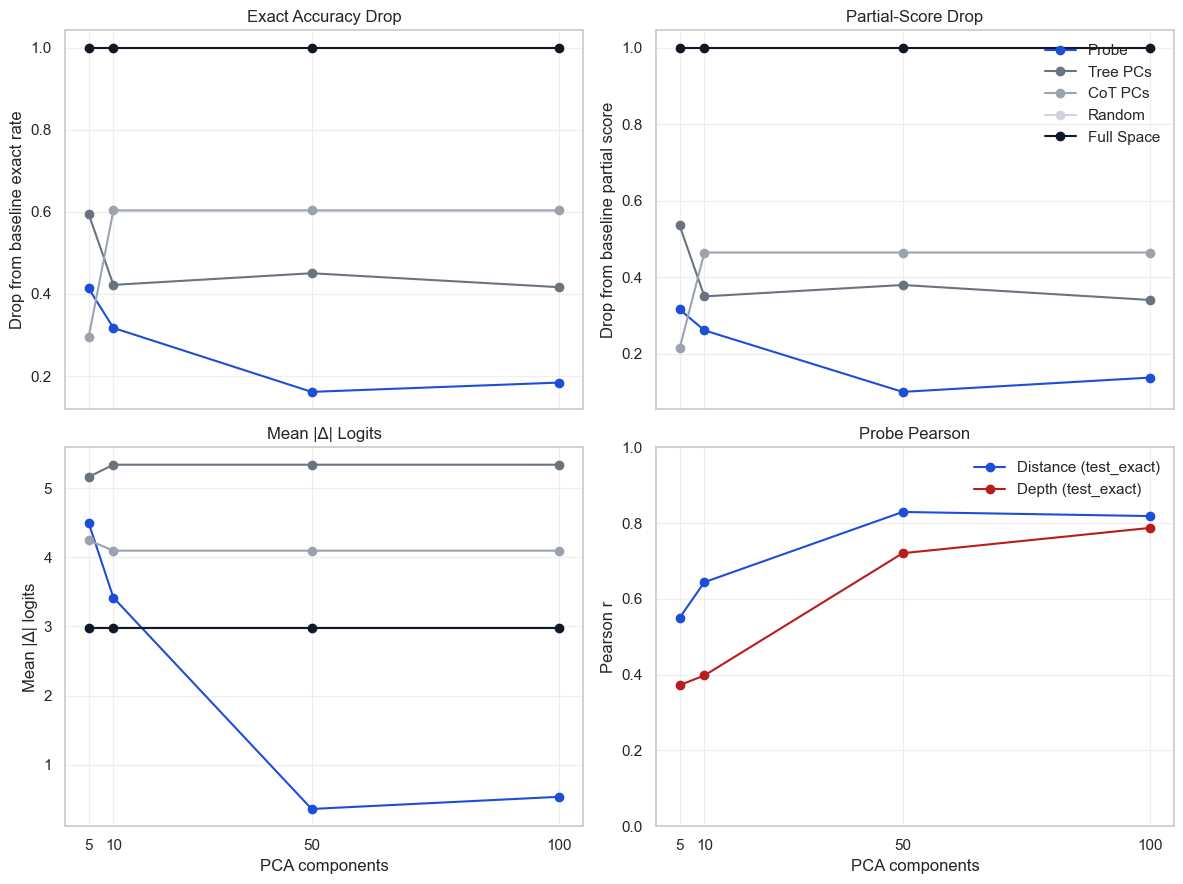

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
components = sweep_df["pca_components"].to_numpy()

# Exact accuracy drop
ax = axes[0, 0]
ax.plot(components, sweep_df["probe_exact_drop"], marker="o", color=PROBE_COLOR, label="Probe")
ax.plot(components, sweep_df["tree_pca_exact_drop"], marker="o", color=TREE_PCA_COLOR, label="Tree PCs")
ax.plot(components, sweep_df["cot_pca_exact_drop"], marker="o", color=COT_PCA_COLOR, label="CoT PCs")
if INCLUDE_BASELINES:
    ax.plot(components, sweep_df["random_exact_drop"], marker="o", color=RANDOM_COLOR, label="Random")
    ax.plot(components, sweep_df["full_space_exact_drop"], marker="o", color=FULL_SPACE_COLOR, label="Full Space")
ax.set_title("Exact Accuracy Drop")
ax.set_ylabel("Drop from baseline exact rate")
ax.grid(True, alpha=0.3)

# Partial-score drop
ax = axes[0, 1]
ax.plot(components, sweep_df["probe_partial_drop"], marker="o", color=PROBE_COLOR, label="Probe")
ax.plot(components, sweep_df["tree_pca_partial_drop"], marker="o", color=TREE_PCA_COLOR, label="Tree PCs")
ax.plot(components, sweep_df["cot_pca_partial_drop"], marker="o", color=COT_PCA_COLOR, label="CoT PCs")
if INCLUDE_BASELINES:
    ax.plot(components, sweep_df["random_partial_drop"], marker="o", color=RANDOM_COLOR, label="Random")
    ax.plot(components, sweep_df["full_space_partial_drop"], marker="o", color=FULL_SPACE_COLOR, label="Full Space")
ax.set_title("Partial-Score Drop")
ax.set_ylabel("Drop from baseline partial score")
ax.grid(True, alpha=0.3)

# Logit difference
ax = axes[1, 0]
ax.plot(components, sweep_df["probe_logit_diff"], marker="o", color=PROBE_COLOR, label="Probe")
ax.plot(components, sweep_df["tree_pca_logit_diff"], marker="o", color=TREE_PCA_COLOR, label="Tree PCs")
ax.plot(components, sweep_df["cot_pca_logit_diff"], marker="o", color=COT_PCA_COLOR, label="CoT PCs")
if INCLUDE_BASELINES:
    ax.plot(components, sweep_df["random_logit_diff"], marker="o", color=RANDOM_COLOR, label="Random")
    ax.plot(components, sweep_df["full_space_logit_diff"], marker="o", color=FULL_SPACE_COLOR, label="Full Space")
ax.set_title("Mean |Δ| Logits")
ax.set_xlabel("PCA components")
ax.set_ylabel("Mean |Δ| logits")
ax.grid(True, alpha=0.3)

# Probe quality
ax = axes[1, 1]
ax.plot(components, sweep_df["probe_distance_pearson"], marker="o", color=DISTANCE_COLOR, label=f"Distance ({PROBE_DISTANCE_SPLIT})")
ax.plot(components, sweep_df["probe_depth_pearson"], marker="o", color=DEPTH_COLOR, label=f"Depth ({PROBE_DEPTH_SPLIT})")
ax.set_title("Probe Pearson")
ax.set_xlabel("PCA components")
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xticks(components)

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 1].legend(handles, labels, loc="best", frameon=False)
handles, labels = axes[1, 1].get_legend_handles_labels()
axes[1, 1].legend(handles, labels, loc="best", frameon=False)

plt.tight_layout()
plt.show()

In [6]:
summary_cols = [
    "pca_components",
    "probe_exact_drop",
    "tree_pca_exact_drop",
    "probe_logit_diff",
    "tree_pca_logit_diff",
    "probe_distance_pearson",
    "probe_depth_pearson",
]
summary_df = sweep_df[summary_cols].copy()
summary_df

,pca_components,probe_exact_drop,tree_pca_exact_drop,probe_logit_diff,tree_pca_logit_diff,probe_distance_pearson,probe_depth_pearson
0,5,0.413598,0.594901,4.498236,5.161699,0.550275,0.372346
1,10,0.317280,0.422096,3.416119,5.338463,0.644397,0.397961
2,50,0.161473,0.450425,0.359472,5.338705,0.829737,0.720828
3,100,0.184136,0.416431,0.535555,5.338346,0.818896,0.787766


In [7]:
best_probe_distance = sweep_df.sort_values("probe_distance_pearson", ascending=False).iloc[0]
best_probe_depth = sweep_df.sort_values("probe_depth_pearson", ascending=False).iloc[0]
smallest_probe_drop = sweep_df.sort_values("probe_exact_drop", ascending=True).iloc[0]

print(
    f"Best distance probe Pearson: pca={int(best_probe_distance['pca_components'])} "
    f"(r={best_probe_distance['probe_distance_pearson']:.3f})"
)
print(
    f"Best depth probe Pearson: pca={int(best_probe_depth['pca_components'])} "
    f"(r={best_probe_depth['probe_depth_pearson']:.3f})"
)
print(
    f"Smallest probe exact drop: pca={int(smallest_probe_drop['pca_components'])} "
    f"(drop={smallest_probe_drop['probe_exact_drop']:.3f}, logit={smallest_probe_drop['probe_logit_diff']:.3f})"
)

Best distance probe Pearson: pca=50 (r=0.830)
Best depth probe Pearson: pca=100 (r=0.788)
Smallest probe exact drop: pca=50 (drop=0.161, logit=0.359)
